In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score


EDA

Task 1 : Exploratory Data Analysis (EDA)   
Apply all EDA Python techniques you learned in the labs to answer the following questions:   
• Are there any missing values? How many, and in which columns?   
• What does the distribution of Value Per M$ look like? Is it approximately normal or
skewed? Compute the skewness.   
• Which numerical features seem most related to Value Per M$?   
• What is the average Overall_Rating per Position?

In [2]:
df = pd.read_csv("Fifa.csv")
df.shape

(19667, 9)

In [3]:
df.isnull().sum()
# no null values

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

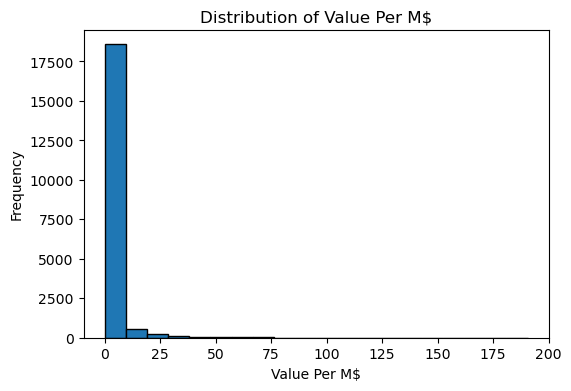

In [4]:
df['Value Per M$'].hist(figsize=(6,4), bins=20, edgecolor='black')
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.grid(0)
plt.show()  #right skewed distribution

In [5]:
df['Value Per M$'].skew() #normal = 0 right skewed > 0 left skewed < 0

np.float64(7.983215201865151)

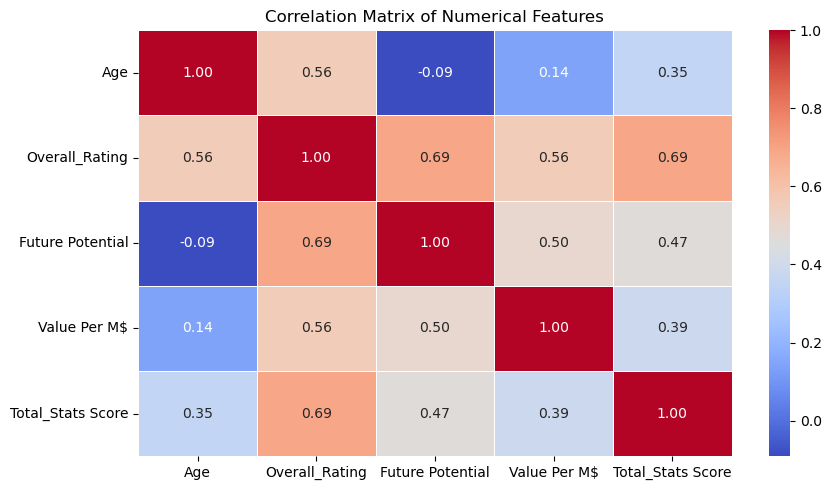

In [6]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

#numerical features seem most related to Value Per M$
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(9,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
position_overall = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(position_overall)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


C:\Users\meria\AppData\Local\Temp\ipykernel_97604\907945268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_overall.index, y=position_overall.values, palette="coolwarm")


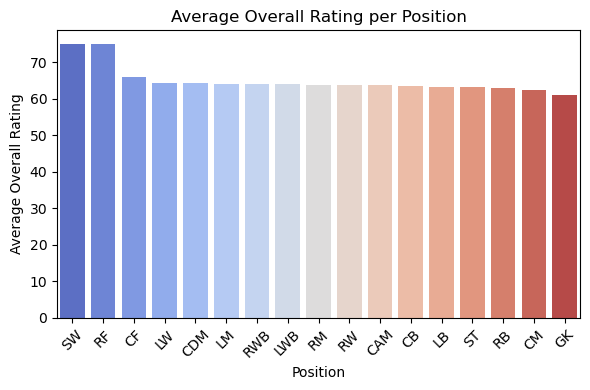

In [8]:
# the average Overall_Rating per Position -> groupby position and calculate mean of Overall_Rating
position_overall = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=position_overall.index, y=position_overall.values, palette="coolwarm")
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

preprocessing

Task 2 : Data Preprocessing  
Apply the same preprocessing steps for all models. You must:  
• Split the dataset into Train and Test sets (80/20) before applying any preprocessing
step.   
• Encode categorical columns  
• Scale numerical features   
• Detect and handle outliers

Split -> Encode -> outliers -> Scaling

In [9]:
# drop name column
df = df.drop(columns=['Name'])

In [10]:
# Split the dataset into Train and Test sets (80/20) before applying any preprocessing step
X = df.drop(columns=['Value Per M$'])
y = df['Value Per M$']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80% train, 20% test, random_state for reproducibility

In [11]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist() #select numerical columns for scaling before one-hot encoding
print("Numerical Columns:", numerical_features)

Numerical Columns: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']


In [12]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)

Categorical Features: ['Country', 'Position', 'Team']


In [13]:
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(df[col].nunique())


Column: Country
164

Column: Position
17

Column: Team
1009


target encoding for country & team   

one-hot encoding for position

In [14]:
x_train = X_train.copy() # avoid leakage
x_test = X_test.copy() # avoid leakage
x_train['Value Per M$'] = y_train # append target variable to training data for encoding

In [15]:
# target encoding for country and team columns
target_col = ['Country', 'Team']
for col in target_col:
    target_mean = x_train.groupby(col)['Value Per M$'].mean() #calculate mean value Per M$ for each category in each column
    X_train[col] = x_train[col].map(target_mean) #replace each category with its corresponding mean value Per M$
    X_test[col] = X_test[col].map(target_mean)

global_y_mean = y_train.mean() #fill missing values in test set with mean value Per M$ from training set
for col in target_col:
    X_test[col] = X_test[col].fillna(global_y_mean)


# one-hot encoding for position column
one = OneHotEncoder(sparse_output=False, handle_unknown='ignore') #handle_unknown='ignore' to ignore unseen categories in test set
one.fit(X_train[['Position']]) #fit encoder on training data
position_train_encoded = one.transform(X_train[['Position']]) #transform training data
position_test_encoded = one.transform(X_test[['Position']]) #transform test data
position_train_df = pd.DataFrame(position_train_encoded, columns=one.get_feature_names_out(['Position']), index=X_train.index) #dataframe->training
position_test_df = pd.DataFrame(position_test_encoded, columns=one.get_feature_names_out(['Position']), index=X_test.index) #dataframe->encoded test
X_train = pd.concat([X_train.drop(columns=['Position']), position_train_df], axis=1) #concatenate encoded training data with original training data (after dropping position column)
X_test = pd.concat([X_test.drop(columns=['Position']), position_test_df], axis=1) #concatenate encoded test data with original test data (after dropping position column)

Detect and handle outliers

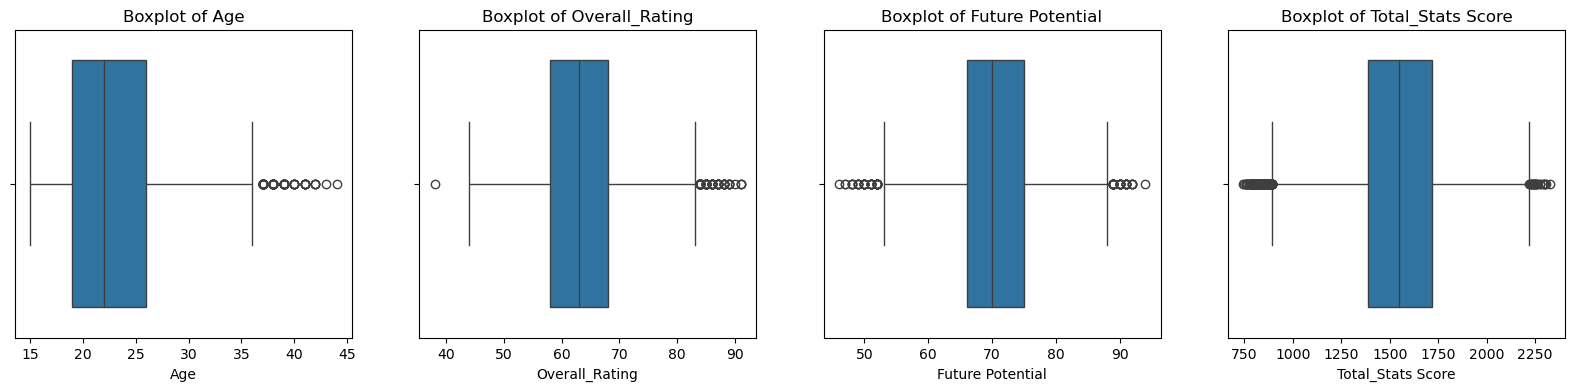

In [16]:
# explore outliers in numerical features using boxplots
plt.figure(figsize=(20,4))
for i, col in enumerate(numerical_features):
    plt.subplot(1, 4, i+1) # 1 row, 4 columns, current plot index = i+1
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
plt.show()

In [17]:
q1 = X_train[numerical_features].quantile(0.25)
q3 = X_train[numerical_features].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = ((X_train[numerical_features] < lower_bound) | (X_train[numerical_features] > upper_bound)).sum()
print("\nNumber of Outliers in Each Numerical Feature:\n", outliers)


Number of Outliers in Each Numerical Feature:
 Age                  129
Overall_Rating       111
Future Potential      94
Total_Stats Score    666
dtype: int64


handle outliers by capping them to the upper and lower bounds

In [18]:
# handle outliers by capping them to the upper and lower bounds
X_train[numerical_features] = X_train[numerical_features].clip(lower=lower_bound,upper=upper_bound,axis=1)
X_test[numerical_features] = X_test[numerical_features].clip(lower=lower_bound,upper=upper_bound,axis=1)

Scale numerical features  

In [19]:
# scaling by standard scaler
scaler = StandardScaler()
print("Before Scaling:")
print(X_train[numerical_features].describe())
print('_' * 70)
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features]) #fit and transform training data
X_test[numerical_features] = scaler.transform(X_test[numerical_features]) #transform test data using the same scaler fitted on training data
print("\nAfter Scaling:")
print(X_train[numerical_features].describe())

Before Scaling:
                Age  Overall_Rating  Future Potential  Total_Stats Score
count  15733.000000    15733.000000      15733.000000        15733.00000
mean      22.979819       63.220238         70.664527         1535.38594
std        4.638583        7.728253          6.455405          279.06922
min       15.000000       43.000000         52.500000          892.50000
25%       19.000000       58.000000         66.000000         1389.00000
50%       22.000000       63.000000         70.000000         1548.00000
75%       26.000000       68.000000         75.000000         1720.00000
max       36.500000       83.000000         88.500000         2216.50000
______________________________________________________________________

After Scaling:
                Age  Overall_Rating  Future Potential  Total_Stats Score
count  1.573300e+04    1.573300e+04      1.573300e+04       1.573300e+04
mean  -1.336812e-16   -1.792954e-16      1.237454e-16       2.301033e-16
std    1.000032e+00  

Task 3 : Create Classification Target (Logistic Regression + Naïve Bayes)        

Use the dataset to classify players into 4 performance tiers based on Overall_Rating or
Total_Stats Score   
• Decide on the thresholds for each category.     
• Justify your thresholds — use the data distribution (percentiles or histogram) to support
your decision.        
• Show how many players fall into each category after splitting.           
• Plot a bar chart showing the class distribution. Is it balanced or imbalanced?

In [20]:
# create classification target based on Overall_Rating using percentiles as thresholds
overall_rating = X_train['Overall_Rating']
percentiles = overall_rating.quantile([0.25, 0.60, 0.90])
print("Overall_Rating Percentiles:\n", percentiles)
# define thresholds based on percentiles
thresholds = [overall_rating.min(), percentiles[0.25], percentiles[0.60], percentiles[0.90], overall_rating.max()]
labels = ['Low', 'Mid', 'High', 'Elite'] # assign performance tiers based on thresholds
X_train['Performance_Tier'] = pd.cut(X_train['Overall_Rating'], bins=thresholds, labels=labels, include_lowest=True)
print("\nPerformance Tier Distribution in each category:\n", X_train['Performance_Tier'].value_counts())

Overall_Rating Percentiles:
 0.25   -0.675496
0.60    0.230300
0.90    1.394895
Name: Overall_Rating, dtype: float64

Performance Tier Distribution in each category:
 Performance_Tier
Mid      5738
Low      4403
High     4159
Elite    1433
Name: count, dtype: int64


We used quartile based thresholds 25% 60% 90% to divide players into four performance categories   
this ensures avoid bias   
reflects the normal distribution

C:\Users\meria\AppData\Local\Temp\ipykernel_97604\1079623388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance_Tier', data=X_train, order=['Low', 'Mid', 'High', 'Elite'], palette='coolwarm')


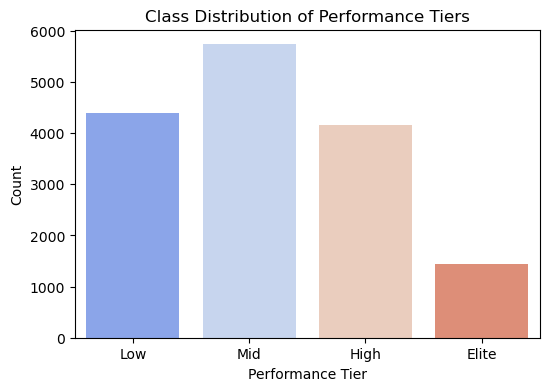

In [21]:
# plot class distribution of performance tiers
plt.figure(figsize=(6,4))
sns.countplot(x='Performance_Tier', data=X_train, order=['Low', 'Mid', 'High', 'Elite'], palette='coolwarm')
plt.title('Class Distribution of Performance Tiers')
plt.xlabel('Performance Tier')
plt.ylabel('Count')
plt.show()

The class distribution is imbalanced because differing numbers of players in each performance tier   
low & mid >> high & elite

# Polynomial Regression

Train regression models to predict the player market value.

• Train a baseline Linear Regression model and evaluate it using: MAE, MSE, RMSE, and R2 score on both train and test sets.

• Use PolynomialFeatures to expand the numerical features only for degree = 1, 2, 3, and 4 if needed.

• For each degree, record Train R2 and Test R2. Plot degree vs. performance. What trend do you observe?

• Which degree gives the best generalization? Justify using the train/test gap.

In [22]:
x_train_reg = X_train.drop(columns=['Performance_Tier'])

lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train_reg,y_train)
y_predicted = lin_reg_model.predict(X_test)

# running .predict on X_train to get x_train_pred for mse/mae...etc
y_train_pred = lin_reg_model.predict(x_train_reg)

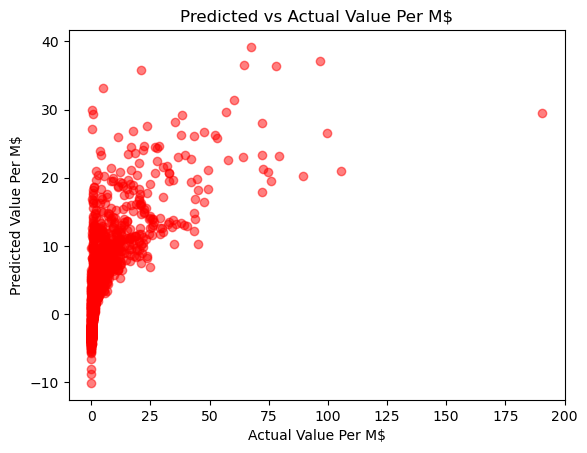

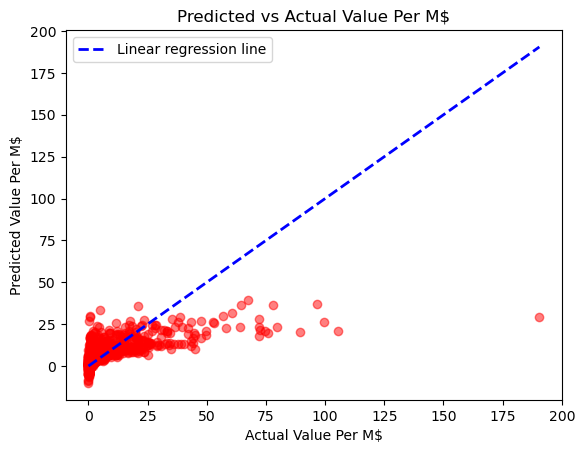

In [23]:
plt.scatter(y_test, y_predicted,color='red', alpha = 0.5)
plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.show()   # without regression line

plt.scatter(y_test, y_predicted, color='red', alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label = "Linear regression line")
plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.legend()
plt.show()  # with regression line, graph is now squished which indicates underfitting

In [24]:
print("Test Data Evaluation:")
mae_test = mean_absolute_error(y_test,y_predicted)
mse_test = mean_squared_error(y_test,y_predicted)
rmse_test = root_mean_squared_error(y_test,y_predicted)
r2_test = r2_score(y_test,y_predicted)
print(f"MAE: {mae_test}\nMSE: {mse_test}\nRMSE: {rmse_test}\nR2 Score: {r2_test}\n")

print("Train Data Evaluation:")
mae_train = mean_absolute_error(y_train,y_train_pred)
mse_train = mean_squared_error(y_train,y_train_pred)
rmse_train = root_mean_squared_error(y_train,y_train_pred)
r2_train = r2_score(y_train,y_train_pred)
print(f"MAE: {mae_train}\nMSE: {mse_train}\nRMSE: {rmse_train}\nR2 Score: {r2_train}\n")

Test Data Evaluation:
MAE: 2.4582040941255174
MSE: 33.5150016480415
RMSE: 5.789214251350653
R2 Score: 0.4597131400292527

Train Data Evaluation:
MAE: 2.383926717127439
MSE: 25.763692878212527
RMSE: 5.075794802610969
R2 Score: 0.4879517404724909



In [25]:
# Polynomial, first transform the data into x^2/ x1 * x2 ...etc features, then apply lin reg model to it
# 1 degree (same as linear model, should have no change in evaluation)
polynomial_1 = PolynomialFeatures(degree=1, include_bias=False)

x_train_first_degree_polynomial = polynomial_1.fit_transform(x_train_reg[numerical_features])
x_test_first_degree_polynomial = polynomial_1.transform(X_test[numerical_features])   # only want numerical features expanded

x_train_first_degree_df = pd.DataFrame(x_train_first_degree_polynomial, columns=polynomial_1.get_feature_names_out(numerical_features), index=x_train_reg.index)
x_test_first_degree_df = pd.DataFrame(x_test_first_degree_polynomial, columns=polynomial_1.get_feature_names_out(numerical_features), index=X_test.index)

# concat to the og df

x_train_first_degree_final = pd.concat([x_train_reg.drop(columns=numerical_features), x_train_first_degree_df], axis=1)
x_test_first_degree_final = pd.concat([X_test.drop(columns=numerical_features), x_test_first_degree_df], axis=1)

first_degree_polynomial = LinearRegression()
first_degree_polynomial.fit(x_train_first_degree_final, y_train)
y_predicted_first_degree = first_degree_polynomial.predict(x_test_first_degree_final)

y_train_first_degree_pred = first_degree_polynomial.predict(x_train_first_degree_final)

In [26]:
# 2 degrees (x^2)
polynomial_2 = PolynomialFeatures(degree=2, include_bias= False)

x_train_second_degree_polynomial = polynomial_2.fit_transform(x_train_reg[numerical_features])
x_test_second_degree_polynomial = polynomial_2.transform(X_test[numerical_features])

x_train_second_degree_df = pd.DataFrame(x_train_second_degree_polynomial, columns=polynomial_2.get_feature_names_out(numerical_features), index=x_train_reg.index)
x_test_second_degree_df = pd.DataFrame(x_test_second_degree_polynomial, columns=polynomial_2.get_feature_names_out(numerical_features), index=X_test.index)

x_train_second_degree_final = pd.concat([x_train_reg.drop(columns=numerical_features), x_train_second_degree_df], axis=1)
x_test_second_degree_final = pd.concat([X_test.drop(columns=numerical_features), x_test_second_degree_df], axis=1)

second_degree_polynomial = LinearRegression()
second_degree_polynomial.fit(x_train_second_degree_final, y_train)
y_predicted_second_degree = second_degree_polynomial.predict(x_test_second_degree_final)

y_train_second_degree_pred = second_degree_polynomial.predict(x_train_second_degree_final)

In [27]:
# 3 degrees
polynomial_3 = PolynomialFeatures(degree=3, include_bias=False)

x_train_third_degree_polynomial = polynomial_3.fit_transform(x_train_reg[numerical_features])
x_test_third_degree_polynomial = polynomial_3.transform(X_test[numerical_features])

x_train_third_degree_df = pd.DataFrame(x_train_third_degree_polynomial, columns=polynomial_3.get_feature_names_out(numerical_features), index=x_train_reg.index)
x_test_third_degree_df = pd.DataFrame(x_test_third_degree_polynomial, columns=polynomial_3.get_feature_names_out(numerical_features), index=X_test.index)

x_train_third_degree_final = pd.concat([x_train_reg.drop(columns=numerical_features), x_train_third_degree_df], axis=1)
x_test_third_degree_final = pd.concat([X_test.drop(columns=numerical_features), x_test_third_degree_df], axis=1)

third_degree_polynomial = LinearRegression()
third_degree_polynomial.fit(x_train_third_degree_final, y_train)
y_predicted_third_degree = third_degree_polynomial.predict(x_test_third_degree_final)

y_train_third_degree_pred = third_degree_polynomial.predict(x_train_third_degree_final)

In [28]:
# 4 degrees
polynomial_4 = PolynomialFeatures(degree=4, include_bias=False)

x_train_fourth_degree_polynomial = polynomial_4.fit_transform(x_train_reg[numerical_features])
x_test_fourth_degree_polynomial = polynomial_4.transform(X_test[numerical_features])

x_train_fourth_degree_df = pd.DataFrame(x_train_fourth_degree_polynomial, columns=polynomial_4.get_feature_names_out(numerical_features), index=x_train_reg.index)
x_test_fourth_degree_df = pd.DataFrame(x_test_fourth_degree_polynomial, columns=polynomial_4.get_feature_names_out(numerical_features), index=X_test.index)

x_train_fourth_degree_final = pd.concat([x_train_reg.drop(columns=numerical_features), x_train_fourth_degree_df], axis=1)
x_test_fourth_degree_final = pd.concat([X_test.drop(columns=numerical_features), x_test_fourth_degree_df], axis=1)

fourth_degree_polynomial = LinearRegression()
fourth_degree_polynomial.fit(x_train_fourth_degree_final, y_train)
y_predicted_fourth_degree = fourth_degree_polynomial.predict(x_test_fourth_degree_final)

y_train_fourth_degree_pred = fourth_degree_polynomial.predict(x_train_fourth_degree_final)

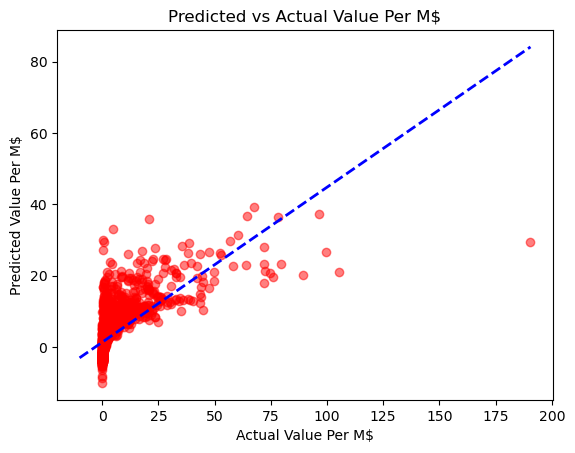

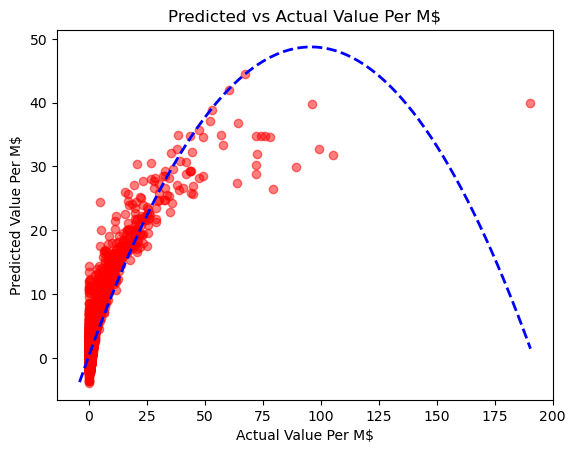

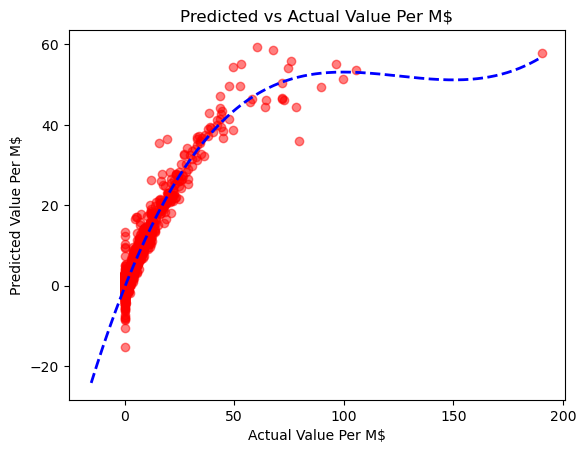

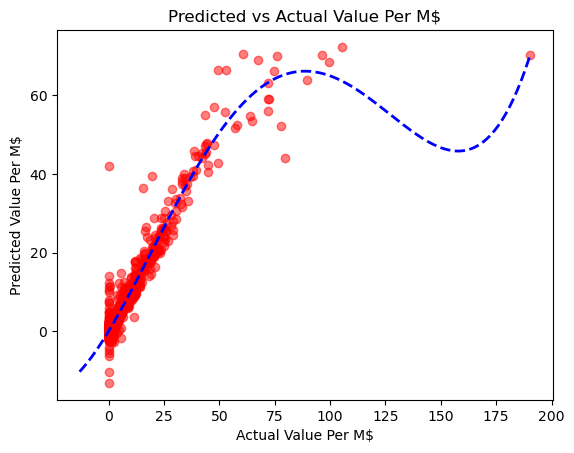

In [29]:
# plot for each degree

plt.scatter(y_test, y_predicted_first_degree, color='red', alpha = 0.5)

min_val_1 = min(y_test.min(), y_predicted_first_degree.min())
max_val_1 = max(y_test.max(), y_predicted_first_degree.max())
sort_index = np.argsort(y_test)  # sort by actual values for a smooth line
x_sorted_1 = np.array(y_test)[sort_index]
y_sorted_1 = np.array(y_predicted_first_degree)[sort_index]
x_line = np.linspace(min_val_1, max_val_1, 300)

coeffs = np.polyfit(x_sorted_1, y_sorted_1, 1)   # takes our points and finds the best polynomial that passes thru all of them
poly = np.poly1d(coeffs)

plt.plot(x_line, poly(x_line), 'b--', lw = 2)

plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.show()  # same as the linear model

#2nd degree
plt.scatter(y_test, y_predicted_second_degree, color='red', alpha = 0.5)

min_val_2 = min(y_test.min(), y_predicted_second_degree.min())
max_val_2 = max(y_test.max(), y_predicted_second_degree.max())

x_sorted_2 = np.array(y_test)[sort_index]
y_sorted_2 = np.array(y_predicted_second_degree)[sort_index]
x_line = np.linspace(min_val_2, max_val_2, 300)

coeffs = np.polyfit(x_sorted_2, y_sorted_2, 2)   # takes our points and finds the best polynomial that passes thru all of them
poly = np.poly1d(coeffs)

plt.plot(x_line, poly(x_line), 'b--', lw = 2)

plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.show()

#3rd degree
plt.scatter(y_test, y_predicted_third_degree, color='red', alpha = 0.5)

min_val_3 = min(y_test.min(), y_predicted_third_degree.min())
max_val_3 = max(y_test.max(), y_predicted_third_degree.max())

x_sorted_3 = np.array(y_test)[sort_index]
y_sorted_3 = np.array(y_predicted_third_degree)[sort_index]
x_line = np.linspace(min_val_3, max_val_3, 300)

coeffs = np.polyfit(x_sorted_3, y_sorted_3, 3)   # takes our points and finds the best polynomial that passes thru all of them
poly = np.poly1d(coeffs)

plt.plot(x_line, poly(x_line), 'b--', lw = 2)

plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.show()

#4th degree
plt.scatter(y_test, y_predicted_fourth_degree, color='red', alpha = 0.5)

min_val_4 = min(y_test.min(), y_predicted_fourth_degree.min())
max_val_4 = max(y_test.max(), y_predicted_fourth_degree.max())

x_sorted_4 = np.array(y_test)[sort_index]
y_sorted_4 = np.array(y_predicted_fourth_degree)[sort_index]
x_line = np.linspace(min_val_4, max_val_4, 300)

coeffs = np.polyfit(x_sorted_4, y_sorted_4, 4)
poly = np.poly1d(coeffs)

plt.plot(x_line, poly(x_line), 'b--', lw = 2)

plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.title("Predicted vs Actual Value Per M$")
plt.show()

In [30]:
# R2 score for each degree
# for first degree, same evaluation results as the lin reg model
r2_train_1 = r2_train
r2_test_1 = r2_test

r2_test_2 = r2_score(y_test,y_predicted_second_degree)
r2_train_2 = r2_score(y_train, y_train_second_degree_pred)

r2_test_3 = r2_score(y_test,y_predicted_third_degree)
r2_train_3 = r2_score(y_train, y_train_third_degree_pred)

r2_test_4 = r2_score(y_test,y_predicted_fourth_degree)
r2_train_4 = r2_score(y_train, y_train_fourth_degree_pred)

print(f"R2 Score for first degree:\nTrain: {r2_train_1}\nTest: {r2_test_1}")
print(f"R2 Score for second degree:\nTrain: {r2_train_2}\nTest: {r2_test_2}")
print(f"R2 Score for third degree:\nTrain: {r2_train_3}\nTest: {r2_test_3}")
print(f"R2 Score for fourth degree:\nTrain: {r2_train_4}\nTest: {r2_test_4}")

R2 Score for first degree:
Train: 0.4879517404724909
Test: 0.4597131400292527
R2 Score for second degree:
Train: 0.6930221110351087
Test: 0.6482251862045336
R2 Score for third degree:
Train: 0.8585602384918964
Test: 0.8138438785420428
R2 Score for fourth degree:
Train: 0.9219816858321872
Test: 0.8775287810998484


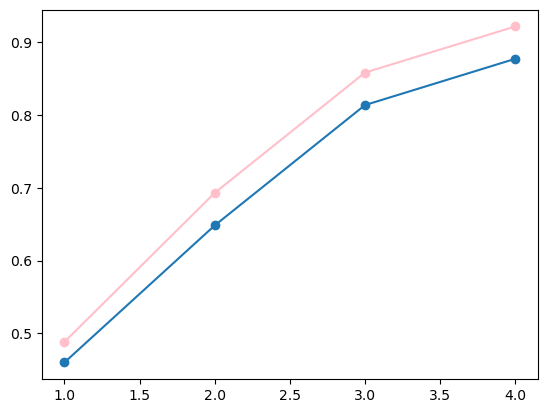

Gap for 1st degree: 0.028238600443238226
Gap for 2nd degree: 0.04479692483057507
Gap for 3rd degree: 0.04471635994985368
Gap for 4th degree: 0.04445290473233876


In [31]:
# degree vs performance
x_axis_scale = [1,2,3,4]
y_train_scores = [r2_train_1, r2_train_2, r2_train_3, r2_train_4]
y_test_scores = [r2_test_1, r2_test_2, r2_test_3, r2_test_4]

plt.plot(x_axis_scale, y_train_scores, label='Train', marker='o', color = 'pink')
plt.plot(x_axis_scale, y_test_scores, label='Test', marker='o')
plt.show()

# gaps in R^2 scores:
print(f"Gap for 1st degree: {r2_train_1 - r2_test_1}")
print(f"Gap for 2nd degree: {r2_train_2 - r2_test_2}")
print(f"Gap for 3rd degree: {r2_train_3 - r2_test_3}")
print(f"Gap for 4th degree: {r2_train_4 - r2_test_4}")

Even though the 1st degree polynomial has the lowest gap in R2 scores, it also has the lowest R2 score for both train and test data, as well as having very clear underfitting as demonstrated by the graph above of the actual market value vs predicted market value.

The best model appears to be the 4th degree polynomial as it has the smallest gap in R2 scores as well as the highest R2 scores among all the other models.

In [32]:
# Regularization
# best polynomial was fourth degree
# renormalize data
new_scaler = StandardScaler()
x_train_fourth_degree_norm = new_scaler.fit_transform(x_train_fourth_degree_final)
x_test_fourth_degree_norm = new_scaler.transform(x_test_fourth_degree_final)


train_rmse_ridge = []
test_rmse_ridge = []

train_rmse_lasso = []
test_rmse_lasso = []

alphas = np.logspace(-3, 3, 30)

for i in range (len(alphas)):
  ridge_for_fourth_degree = Ridge(alpha=alphas[i])
  ridge_for_fourth_degree.fit(x_train_fourth_degree_norm, y_train)
  y_predicted_ridge_fourth_degree = ridge_for_fourth_degree.predict(x_test_fourth_degree_norm)

  rmse_ridge_train = root_mean_squared_error(y_train, ridge_for_fourth_degree.predict(x_train_fourth_degree_norm))
  rmse_ridge_test = root_mean_squared_error(y_test, y_predicted_ridge_fourth_degree)

  train_rmse_ridge.append(rmse_ridge_train)
  test_rmse_ridge.append(rmse_ridge_test)

  lasso_for_fourth_degree = Lasso(alpha=alphas[i], max_iter=10000)
  lasso_for_fourth_degree.fit(x_train_fourth_degree_norm, y_train)
  y_predicted_lasso_fourth_degree = lasso_for_fourth_degree.predict(x_test_fourth_degree_norm)

  rmse_lasso_train = root_mean_squared_error(y_train, lasso_for_fourth_degree.predict(x_train_fourth_degree_norm))
  rmse_lasso_test = root_mean_squared_error(y_test, y_predicted_lasso_fourth_degree)

  train_rmse_lasso.append(rmse_lasso_train)
  test_rmse_lasso.append(rmse_lasso_test)

best_ridge_alpha = alphas[np.argmin(test_rmse_ridge)]
print(f"Best Ridge alpha: {best_ridge_alpha}")

best_index_alpha_lasso = np.argmin(test_rmse_lasso)
best_alpha_lasso = alphas[best_index_alpha_lasso]
print(f"Best Lasso alpha: {best_alpha_lasso}")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.023e+02, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


Best Ridge alpha: 13.738237958832638
Best Lasso alpha: 0.0016102620275609393


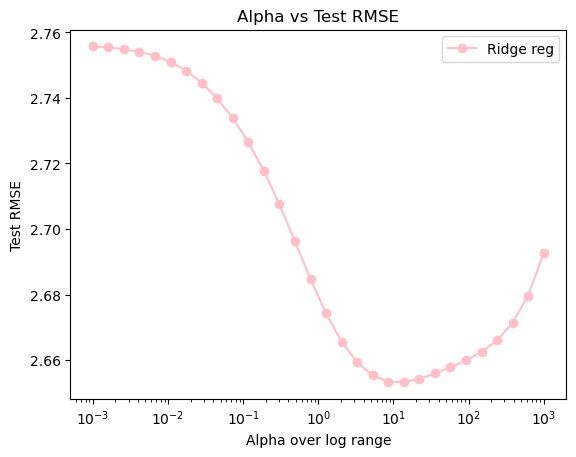

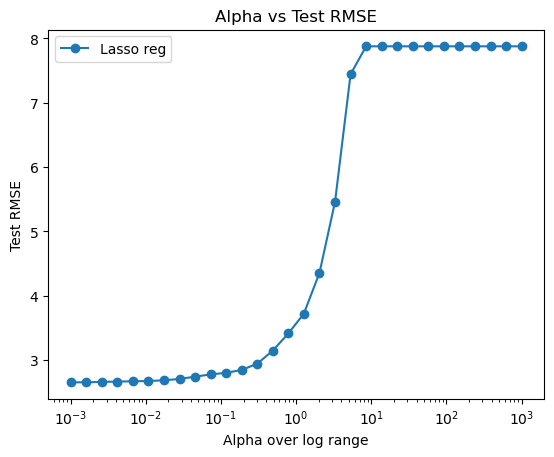

In [33]:
# plots for regularization
plt.plot(alphas, test_rmse_ridge, label='Ridge reg', color= 'pink', marker = 'o')
plt.xscale('log')
plt.title("Alpha vs Test RMSE")
plt.xlabel("Alpha over log range")
plt.ylabel("Test RMSE")
plt.legend()
plt.show()

plt.plot(alphas, test_rmse_lasso, label='Lasso reg', marker = 'o')
plt.xscale('log')
plt.title("Alpha vs Test RMSE")
plt.xlabel("Alpha over log range")
plt.ylabel("Test RMSE")
plt.legend()
plt.show()

For ridge regularization, the RMSE was high at the beginning which indicates overfitting, then as alpha increased, ridge helped lower the coefficients which made the rmse drop at a minimum (optimal alpha value), which is the optimal value to prevent overfitting in the polynomial.

For lasso regularization, the graph starts at a low RMSE which indicates that theres a very small number of useless features, which means there isnt many features that got zeroed out, as alpha increases it starts zeroing out more important features which makes the rmse go up.

In [34]:
# find the zeroed features at optimal alpha = 0.00161
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(x_train_fourth_degree_norm, y_train)

zeroed = np.where(lasso_model.coef_ == 0)[0]
print(f"Zeroed feature indices: {zeroed.tolist()}")

cols = x_train_fourth_degree_final.columns
zeroed_cols = cols[zeroed]
print(f"Zeroed columns by lasso: {zeroed_cols}")

Zeroed feature indices: [3, 20, 29, 35, 45, 61, 62, 66, 67, 68, 79, 86, 87]
Zeroed columns by lasso: Index(['Position_CB', 'Overall_Rating', 'Overall_Rating Total_Stats Score',
       'Age^2 Future Potential', 'Overall_Rating^2 Total_Stats Score',
       'Age^2 Future Potential Total_Stats Score', 'Age^2 Total_Stats Score^2',
       'Age Overall_Rating Future Potential^2',
       'Age Overall_Rating Future Potential Total_Stats Score',
       'Age Overall_Rating Total_Stats Score^2',
       'Overall_Rating Future Potential^3',
       'Future Potential Total_Stats Score^3', 'Total_Stats Score^4'],
      dtype='object')


Most of these zeroed features are ones that are expanded in the polynomial, with the only "original" features being Position_CB and Overall_Rating. This suggests the expanded features add nothing to the model and are just noise, while Overall_Rating and Position_CB might either not contribute much to the market value of a player, or be represented in another column like for example Future_Potential or Position_CB being portrayed in another Position column since it is an encoded value

# K fold

In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
neg_mse_scores = cross_val_score(lasso_model, x_train_fourth_degree_norm, y_train , cv=kf, scoring='neg_mean_squared_error')
fold_rmse_scores = np.sqrt(-neg_mse_scores)
mean_rmse = np.mean(fold_rmse_scores)
std_rmse = np.std(fold_rmse_scores)

print("K-Fold Cross-Validation Report (4th Degree Polynomial)")
for i, score in enumerate(fold_rmse_scores, 1):
    print(f"Fold {i} RMSE: {score:.4f}")

print("_" * 50)
print(f"Mean RMSE: {mean_rmse:.4f}")
print(f"Standard Deviation: {std_rmse:.4f}")
print("_" * 50)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.999e+01, tolerance: 6.408e+01
  model = cd_fast.enet_coordinate_descent(


K-Fold Cross-Validation Report (4th Degree Polynomial)
Fold 1 RMSE: 1.7361
Fold 2 RMSE: 2.2264
Fold 3 RMSE: 1.9910
Fold 4 RMSE: 1.8294
Fold 5 RMSE: 2.5164
__________________________________________________
Mean RMSE: 2.0599
Standard Deviation: 0.2824
__________________________________________________


This indicates that the model has relatively stable performance across different folds, as the variation between the RMSE values is moderate.

However, the slightly higher RMSE in Fold 5 suggests that the model's performance may vary depending on the data split.

low Standard Deviation (0.2824) demonstrates that the model is stable and consistent

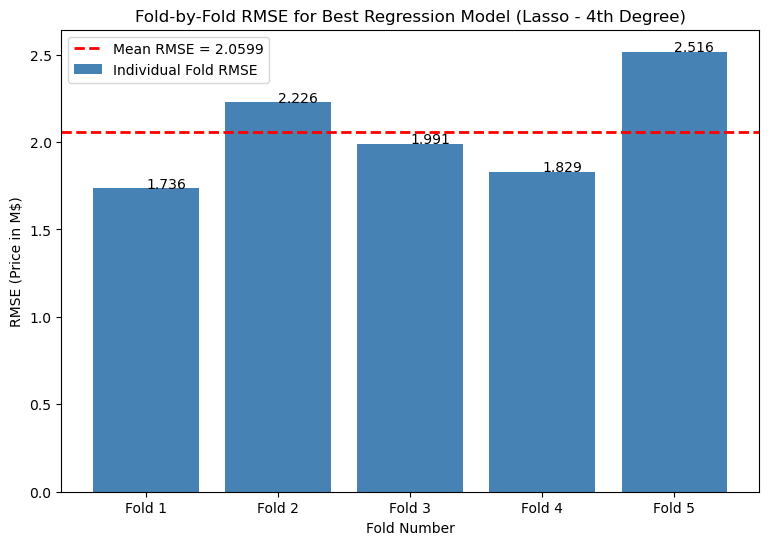

In [36]:
plt.figure(figsize=(9, 6))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
plt.bar(fold_labels, fold_rmse_scores, color='steelblue', label='Individual Fold RMSE')
plt.axhline(y=mean_rmse, color='red', linestyle='--', linewidth=2, label=f'Mean RMSE = {mean_rmse:.4f}')
plt.title('Fold-by-Fold RMSE for Best Regression Model (Lasso - 4th Degree)')
plt.xlabel('Fold Number')
plt.ylabel('RMSE (Price in M$)')
plt.legend()
for i, value in enumerate(fold_rmse_scores):
    plt.text(i, value , f"{value:.3f}")

plt.show()

# Train Logistic Regression Model

We train a baseline Logistic Regression model using default parameters

 max_iter=1000 is used to ensure convergence due to the high number of features after encoding
 The model learns to classify players into performance tiers based on their attributes
After training the model, we use it to predict the performance tier for the test dataset
These predictions will be compared against the true labels to evaluate model performance

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
X_part = X_train.drop(columns=['Performance_Tier', 'Overall_Rating'], errors='ignore')
X_test_part  = X_test.drop(columns=['Performance_Tier', 'Overall_Rating'], errors='ignore')

y_part = X_train['Performance_Tier']

y_test_part = pd.cut(X_test['Overall_Rating'], bins=thresholds, labels=labels, include_lowest=True)

In [39]:
Logistic_model = LogisticRegression(max_iter=1000)
Logistic_model.fit(X_part,y_part)
y_pred = Logistic_model.predict(X_test_part)

We evaluate the model using:
 Precision
 Recall
 F1-score
 Support (number of samples per class)

This provides a detailed view of performance across all classes, which is important due to class imbalance
Accuracy alone is not sufficient for evaluation

In [40]:
print("Train Accuracy:", Logistic_model.score(X_part, y_part))
print("Test Accuracy:", Logistic_model.score(X_test_part, y_test_part))

Train Accuracy: 0.8342973368079832
Test Accuracy: 0.8398576512455516


In [41]:
print(classification_report(y_test_part,y_pred))

              precision    recall  f1-score   support

       Elite       0.87      0.83      0.85       370
        High       0.82      0.80      0.81      1032
         Low       0.90      0.89      0.89      1165
         Mid       0.80      0.83      0.81      1367

    accuracy                           0.84      3934
   macro avg       0.85      0.84      0.84      3934
weighted avg       0.84      0.84      0.84      3934



The confusion matrix helps visualize how well the model performs across different classes

 Diagonal values represent correct predictions
 Off-diagonal values represent misclassifications

This helps identify which classes are being confused with each other

We tune the hyperparameter C, which controls the strength of regularization

 Small C : strong regularization , simpler model , possible underfitting
 Large C : weak regularization , complex model , possible overfitting

We test multiple values of C using a logarithmic scale to find the optimal balance

In [42]:
C_values = np.logspace(-3,3,10)
train_acc = []
test_acc = []
for c in C_values:
    model = LogisticRegression(C=c,max_iter=1000)
    model.fit(X_part,y_part)
    train_acc.append(model.score(X_part,y_part))
    test_acc.append(model.score(X_test_part,y_test_part))

In [43]:
for c, train, test in zip(C_values, train_acc, test_acc):
    print(f"C = {c:.4f} | Train = {train:.3f} | Test = {test:.3f}")

C = 0.0010 | Train = 0.744 | Test = 0.746
C = 0.0046 | Train = 0.790 | Test = 0.796
C = 0.0215 | Train = 0.818 | Test = 0.825
C = 0.1000 | Train = 0.828 | Test = 0.838
C = 0.4642 | Train = 0.832 | Test = 0.841
C = 2.1544 | Train = 0.835 | Test = 0.842
C = 10.0000 | Train = 0.834 | Test = 0.843
C = 46.4159 | Train = 0.834 | Test = 0.842
C = 215.4435 | Train = 0.834 | Test = 0.843
C = 1000.0000 | Train = 0.834 | Test = 0.842


We plot training and testing accuracy against different values of C

 If training accuracy is high but test accuracy is low : overfitting
 If both are low : underfitting
 The optimal C is where test accuracy is maximized with minimal gap

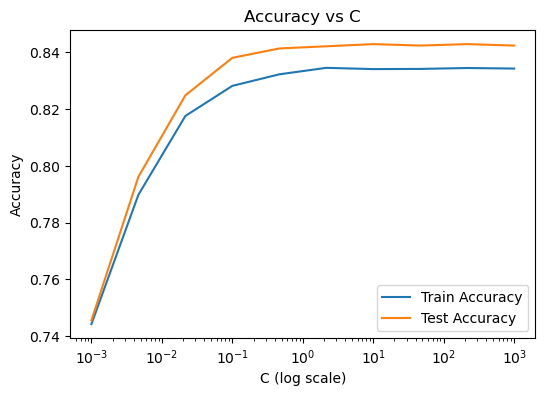

In [44]:
plt.figure(figsize=(6,4))
plt.semilogx(C_values, train_acc, label='Train Accuracy')
plt.semilogx(C_values, test_acc, label='Test Accuracy')

plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C")
plt.legend()
plt.show()

We compare:
 L1 Regularization (Lasso)
 L2 Regularization (Ridge)

L1 can eliminate irrelevant features by setting coefficients to zero
L2 distributes weights across features and is generally better when many encoded features are present

We compare their performance using test accuracy.

In [45]:
best_c =C_values[np.argmax(test_acc)]
model_l2 = LogisticRegression(C=best_c,penalty='l2',max_iter=1000)
model_l2.fit(X_part,y_part)

model_l1 = LogisticRegression(C=best_c,penalty='l1',solver='saga',max_iter=1000)
model_l1.fit(X_part,y_part)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(10.0)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
print("Best C:", best_c)

print("L2 Train Accuracy:", model_l2.score(X_part, y_part))
print("L2 Test Accuracy:", model_l2.score(X_test_part, y_test_part))

print("L1 Train Accuracy:", model_l1.score(X_part, y_part))
print("L1 Test Accuracy:", model_l1.score(X_test_part, y_test_part))

Best C: 10.0
L2 Train Accuracy: 0.8341066548020085
L2 Test Accuracy: 0.8429079816980173
L1 Train Accuracy: 0.8341702154706667
L1 Test Accuracy: 0.8429079816980173


# Naive Bayes

In [47]:
# Set target variables
y_train = X_train['Performance_Tier']
y_test = pd.cut(X_test['Overall_Rating'], bins=thresholds, labels=labels, include_lowest=True) # create target variable for test set using same thresholds

In [48]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
#GaussianNB for numerical features
num_cols=['Age', 'Future Potential', 'Total_Stats Score' ]
X_train_num_cols = X_train[num_cols]
X_test_num_cols = X_test[num_cols]
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train_num_cols, y_train)
y_pred = gaussian_nb.predict(X_test_num_cols)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print("_" * 70)
#Gaussian without scaling
x_train_num_cols = x_train[num_cols]
x_test_num_cols = x_test[num_cols]
gaussian_nb.fit(x_train_num_cols, y_train)
y_pred = gaussian_nb.predict(x_test_num_cols)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))


Accuracy: 0.7524
              precision    recall  f1-score   support

       Elite       0.87      0.66      0.75       370
        High       0.77      0.70      0.73      1032
         Low       0.85      0.74      0.79      1165
         Mid       0.67      0.83      0.74      1367

    accuracy                           0.75      3934
   macro avg       0.79      0.73      0.75      3934
weighted avg       0.77      0.75      0.75      3934

______________________________________________________________________
Accuracy: 0.7506
              precision    recall  f1-score   support

       Elite       0.86      0.66      0.75       370
        High       0.77      0.70      0.73      1032
         Low       0.86      0.73      0.79      1165
         Mid       0.66      0.83      0.74      1367

    accuracy                           0.75      3934
   macro avg       0.79      0.73      0.75      3934
weighted avg       0.77      0.75      0.75      3934



Scaling does not affect GaussianNB because the model relies on the distribution's shape (mean and variance), and linear scaling doesn't change the class probabilities

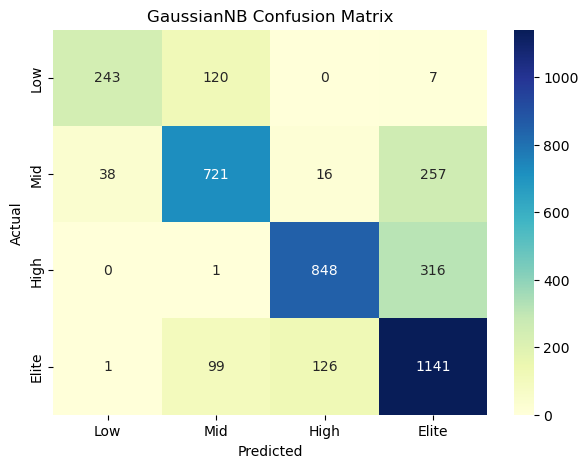

In [50]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels, yticklabels=labels)
plt.title('GaussianNB Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [51]:
#BernoulliNB for one-hot encoded feature
onehot_cols = one.get_feature_names_out(['Position'])
X_train_onehot = X_train[onehot_cols]
X_test_onehot = X_test[onehot_cols]
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train_onehot, y_train)
y_pred_onehot = bernoulli_nb.predict(X_test_onehot)
print(f"Accuracy: {accuracy_score(y_test, y_pred_onehot):.4f}")
print(classification_report(y_test, y_pred_onehot))



Accuracy: 0.3615
              precision    recall  f1-score   support

       Elite       0.00      0.00      0.00       370
        High       0.00      0.00      0.00      1032
         Low       0.44      0.15      0.23      1165
         Mid       0.35      0.91      0.51      1367

    accuracy                           0.36      3934
   macro avg       0.20      0.27      0.18      3934
weighted avg       0.25      0.36      0.24      3934



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


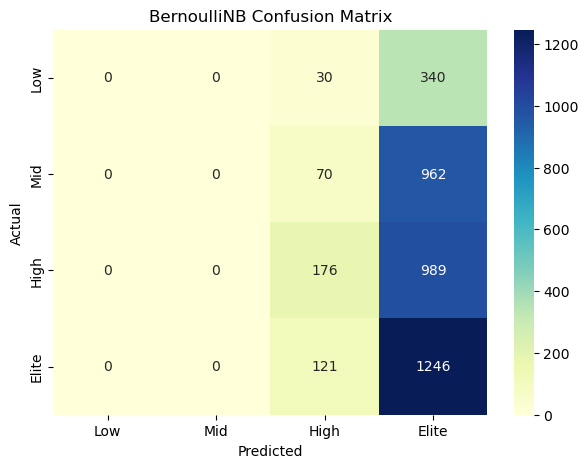

In [52]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_onehot), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels, yticklabels=labels)
plt.title('BernoulliNB Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [53]:
#ComplementNB for ohe feature
X_train_full = X_train.drop(columns=['Performance_Tier', 'Overall_Rating'], errors='ignore')
X_test_full =X_test.drop(columns=['Overall_Rating'], errors='ignore')
#shifting negative values to positive for ComplementNB
train_min_values = X_train_full.min()
X_train_shifted = X_train_full - train_min_values
X_test_shifted = X_test_full - train_min_values
complement_nb = ComplementNB()
complement_nb.fit(X_train_shifted, y_train)
y_pred_complement = complement_nb.predict(X_test_shifted)
print(f"Accuracy: {accuracy_score(y_test, y_pred_complement):.4f}")
print(classification_report(y_test, y_pred_complement))


Accuracy: 0.4408
              precision    recall  f1-score   support

       Elite       0.38      0.78      0.51       370
        High       0.42      0.20      0.27      1032
         Low       0.57      0.38      0.46      1165
         Mid       0.42      0.58      0.49      1367

    accuracy                           0.44      3934
   macro avg       0.45      0.48      0.43      3934
weighted avg       0.46      0.44      0.42      3934



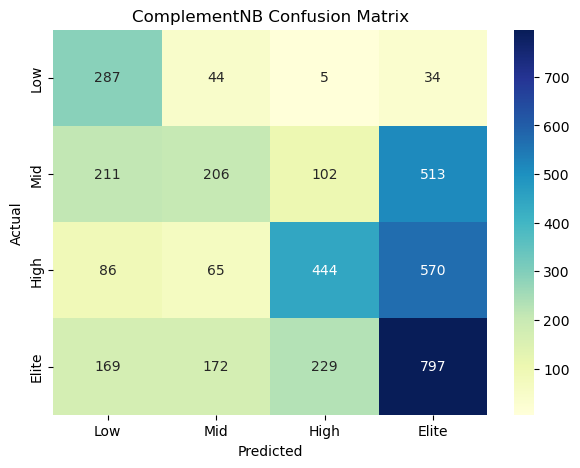

In [54]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_complement), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels, yticklabels=labels)
plt.title('ComplementNB Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The most appropriate model for this dataset is GaussianNB, since the numerical features  such as Age, Future Potential, and Total_Stats Score show a stronger correlation with player value and rating and also based on the implementation results, GaussianNB achieved the highest accuracy 71.02%, making GaussianNB’s probabilistic approach

# Stratified K-Fold

In [55]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logistic_fold_scores = cross_val_score(model_l1, X_part, y_part, cv=skf, scoring='accuracy')
mean_accuracy = np.mean(logistic_fold_scores)
std_accuracy = np.std(logistic_fold_scores)
print("Logistic Regression Cross-Validation ")
for i, score in enumerate(logistic_fold_scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")
print("_" * 40)
print(f"Mean Accuracy of Logistic Regression: {mean_accuracy:.4f}")
print(f"Standard Deviation of Logistic Regression: {std_accuracy:.4f}")
print("_" * 40)

gaussian_nb_fold_scores = cross_val_score(gaussian_nb, X_train_num_cols, y_train, cv=skf, scoring='accuracy')
mean_gaussian_nb_accuracy = np.mean(gaussian_nb_fold_scores)
std_gaussian_nb_accuracy = np.std(gaussian_nb_fold_scores)
print("GaussianNB Cross-Validation")
for i, score in enumerate(gaussian_nb_fold_scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")        
print("_" * 40)
print(f"Mean Accuracy of GaussianNB: {mean_gaussian_nb_accuracy:.4f}")
print(f"Standard Deviation of GaussianNB: {std_gaussian_nb_accuracy:.4f}")
print("_" * 40)



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Cross-Validation 
Fold 1 Accuracy: 0.8411
Fold 2 Accuracy: 0.8262
Fold 3 Accuracy: 0.8246
Fold 4 Accuracy: 0.8392
Fold 5 Accuracy: 0.8271
________________________________________
Mean Accuracy of Logistic Regression: 0.8316
Standard Deviation of Logistic Regression: 0.0070
________________________________________
GaussianNB Cross-Validation
Fold 1 Accuracy: 0.7432
Fold 2 Accuracy: 0.7385
Fold 3 Accuracy: 0.7509
Fold 4 Accuracy: 0.7610
Fold 5 Accuracy: 0.7584
________________________________________
Mean Accuracy of GaussianNB: 0.7504
Standard Deviation of GaussianNB: 0.0086
________________________________________


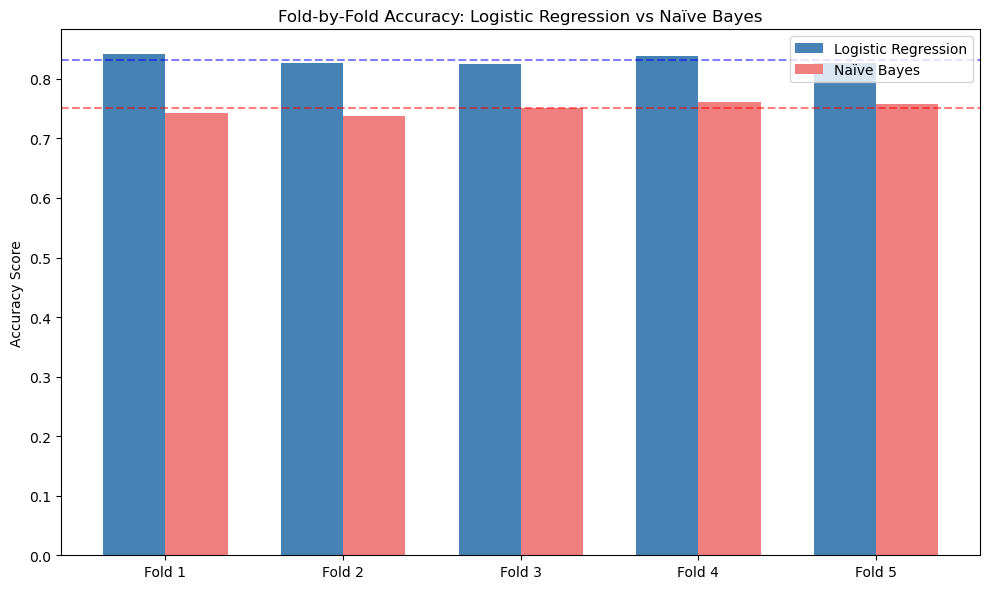

In [56]:
labels = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(len(labels)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, logistic_fold_scores, width, label='Logistic Regression', color='steelblue')
rects2 = ax.bar(x + width/2, gaussian_nb_fold_scores, width, label='Naïve Bayes', color='lightcoral')

ax.set_ylabel('Accuracy Score')
ax.set_title('Fold-by-Fold Accuracy: Logistic Regression vs Naïve Bayes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.axhline(y=mean_accuracy, color='blue', linestyle='--', alpha=0.5, label='Logistic Regression Mean')
ax.axhline(y=mean_gaussian_nb_accuracy, color='red', linestyle='--', alpha=0.5, label='GaussianNB Mean')

plt.tight_layout()
plt.show()

By comparing both models using Stratified 5-Fold Cross-Validation, we conclude that Logistic Regression is the best model for this dataset. It achieved a higher mean accuracy (83.2%) and a lower standard deviation (0.0070), demonstrating better predictive power and higher stability across different data splits compared to GaussianNB (75.04% mean accuracy and 0.0086 std)."

### 8.1 Model Comparison
### Which model performed best overall for regression, and which for classification? Justify briefly.

Regression: The Polynomial Regression (4th Degree) performed best. The 4th-degree polynomial captured complex, non-linear relationships in player attributes

Classification: Logistic Regression was the best model. It achieved a higher mean accuracy of 84.2% compared to GaussianNB’s 75.04%. This is because Logistic Regression can learn specific weights for each feature, whereas Naive Bayes relies that all features are independent.

### Is classification easier or harder than regression on this dataset? Why?

Classification is easier on this dataset. it is simpler to categorize players into broad "Performance Tiers" than it is to predict an exact numerical value . 


### 8.2 Regularization Analysis
### What happened to model performance as you increased alpha in Ridge and Lasso?
Ridge Regression: Initially, at very low alpha values, the Test RMSE was high, indicating that the 4th-degree polynomial model was overfitting the training data. As alpha increased, Ridge regularization began to penalize large coefficients, causing the Test RMSE to drop until it reached its optimal point . Beyond this optimal alpha, the RMSE began to rise again as the model became too simple, leading to underfitting.        

Lasso Regression: The RMSE began to rise almost immediately as alpha increased. This suggests that the features in our dataset are highly relevant; Lasso's aggressive feature selection (setting coefficients exactly to zero) likely removed essential information early on, causing the prediction error to increase steadily.       

In Logistic Regression: using the parameter $C$ (where $C = 1/\alpha$). The model achieved peak performance at $C = 10.0$. At very low $C$ values (high alpha), the model was too restricted, while very high $C$ values (low alpha) risked overfitting.

### Why Ridge often performs better than Lasso with many one-hot encoded features:
Handling Correlated Features:
One-hot encoding creates groups of features that are related to each other (for example, different player positions). Ridge works well in this case because it reduces the values of all these related features together without removing any of them.

Keeping Important Information:
Lasso, on the other hand, tends to choose only one feature from a group and set the others to zero. This can be a problem because even similar features may contain small but useful differences. By removing them, Lasso may lose important information. Ridge keeps all features, so it preserves these details and usually gives more stable and accurate results.